# Simon's Problem

A hidden bit-string `s`. The function `f` gives the **same output for two different
inputs**, and those two inputs always differ by `s`:

```
f(x) = f(x XOR s)
```

Find `s`.

Classically you have to keep evaluating `f` until you stumble on a collision -
two inputs giving the same output. That takes about `2^(n/2)` tries.

Quantumly, each run hands you one clue, and a handful of runs is enough.

In [1]:
# !pip install qiskit qiskit-aer matplotlib pylatexenc

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()

## n = 2, hidden s = 11

We need **two** registers now:

- `q0, q1` - the input
- `q2, q3` - the output of `f`

Here is what this oracle actually computes:

| x | f(x) |
|---|---|
| 00 | 00 |
| 01 | 10 |
| 10 | 10 |
| 11 | 00 |

Look at the pairs. `00` and `11` collide. `01` and `10` collide.
And in both cases the two inputs differ by `11` - which is `s`.

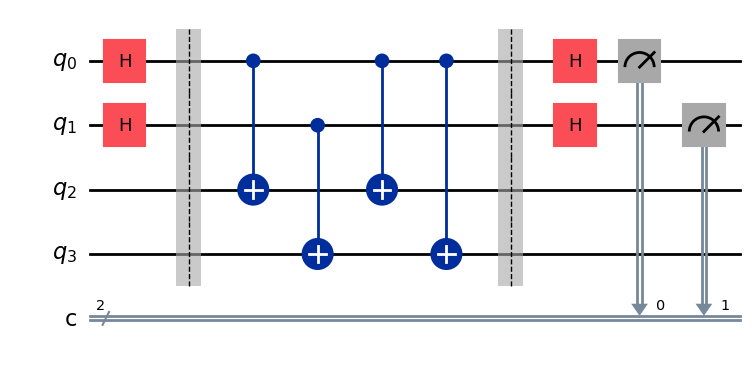

{'11': 508, '00': 516}


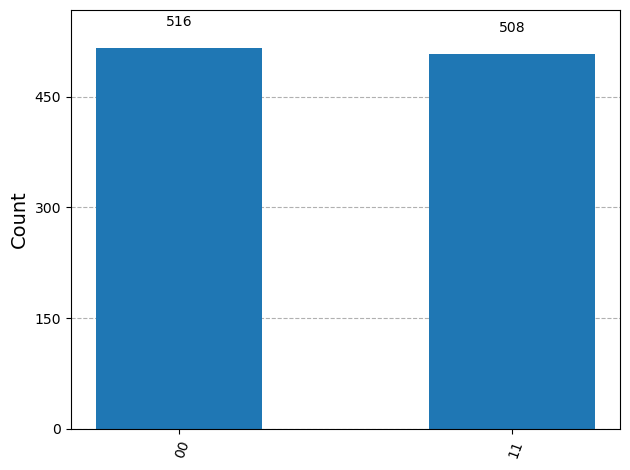

In [2]:
# SIMON n=2, hidden s = 11

qc = QuantumCircuit(4, 2)

qc.h(0)
qc.h(1)
qc.barrier()

# ORACLE for s = 11
qc.cx(0, 2)
qc.cx(1, 3)
qc.cx(0, 2)
qc.cx(0, 3)
qc.barrier()

qc.h(0)
qc.h(1)
qc.measure(0, 0)
qc.measure(1, 1)

display(qc.draw(output="mpl"))

counts = sim.run(transpile(qc, sim), shots=1024).result().get_counts()
print(counts)
display(plot_histogram(counts))

## Reading the output

We got only **`00`** and **`11`**. Never `01`, never `10`.

That is not random. Every string `y` that comes out obeys one rule:

```
y . s = 0   (dot product, mod 2)
```

So each measurement is a **clue about s**, not `s` itself.

- `00` tells us nothing (it is true for every `s`)
- `11` tells us `s0 XOR s1 = 0`, so `s0 = s1`

`s` cannot be `00` (the problem promises it is not), so `s = 11`. **Found it.**

Run the cell again a few times. You get `00` about half the time - a wasted shot.
That is normal. You just run it again.

## n = 3, hidden s = 110

Same structure, one more qubit in each register.

This time one clue will not be enough.

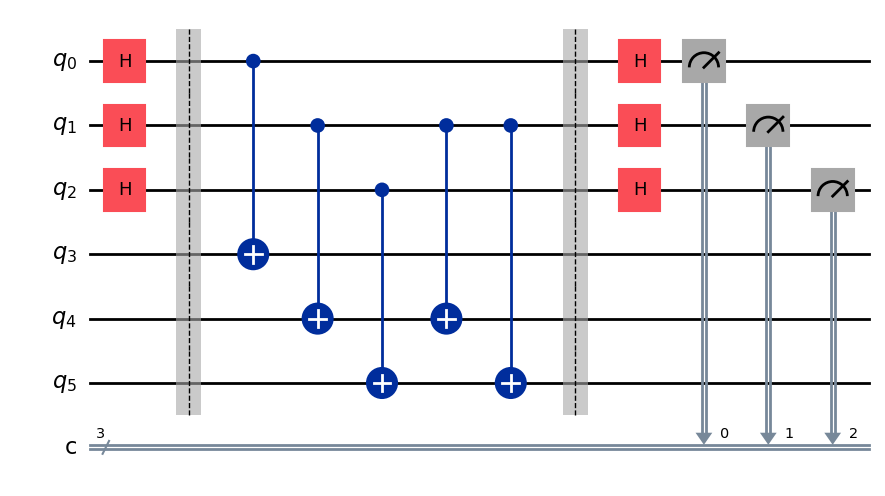

{'111': 544, '110': 479, '000': 502, '001': 523}


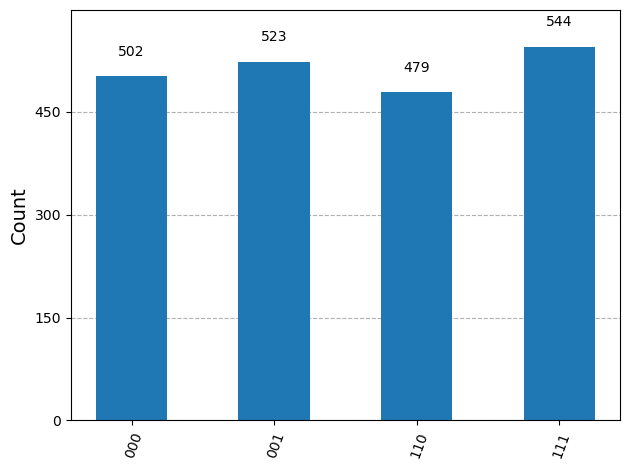

In [3]:
# SIMON n=3, hidden s = 110

qc = QuantumCircuit(6, 3)

qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# ORACLE for s = 110
qc.cx(0, 3)
qc.cx(1, 4)
qc.cx(2, 5)
qc.cx(1, 4)
qc.cx(1, 5)
qc.barrier()

qc.h(0)
qc.h(1)
qc.h(2)
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

display(qc.draw(output="mpl"))

counts = sim.run(transpile(qc, sim), shots=2048).result().get_counts()
print(counts)
display(plot_histogram(counts))

## Reading this one

Four strings show up: `000`, `001`, `110`, `111`. The other four never appear.

Write `s = s2 s1 s0`. Each result gives an equation:

| result | equation | useful? |
|---|---|---|
| `000` | nothing | no |
| `001` | `s0 = 0` | yes |
| `110` | `s2 XOR s1 = 0` | yes |
| `111` | `s2 XOR s1 XOR s0 = 0` | yes |

Take `001` and `110`:

- `s0 = 0`
- `s2 = s1`

So `s` is `000` or `110`. The promise says `s` is not all zeros.

**`s = 110`.**

Notice `111` is just the sum of the other two - it adds nothing new. You need
**n-1 independent** clues, so here, 2. Collect results until you have enough.

## What the circuit is doing

1. `H` on the input - every `x` at once
2. the oracle writes `f(x)` into the second register
3. because `x` and `x XOR s` give the **same** `f`, those two inputs are now stuck
   together in the state
4. `H` on the input again - this interferes them, and everything that disagrees
   with `s` cancels out
5. what survives can only be strings with `y . s = 0`

The second register is never measured. It does its job just by **being entangled**
with the first.

## Why this one mattered

| | queries |
|---|---|
| Classical | about `2^(n/2)` |
| Simon | about `n` |

That is **exponential**, and unlike Deutsch-Jozsa it survives letting the
classical computer use randomness - it is a real separation, not an artifact of
demanding a perfect answer.

Shor read Simon's algorithm and saw that finding a hidden *period* was the same
shape of problem as factoring. Shor's algorithm came out later the same year.

Simon's problem is still a toy. It is the last toy before the real thing.